# Week 4 Coding Quiz Analysis

This notebook analyzes instrumental variables and regression discontinuity concepts using the Week 4 datasets.

The objective is to estimate causal effects using an instrumental variable (IV), compare different methods of estimating the effect, and examine relationships around a cutoff score using regression discontinuity techniques.

In [1]:
import pandas as pd

df = pd.read_csv("homework_4.1.csv")

y_diff = (
    df[df["Z"] == 1]["Y"].mean()
    -
    df[df["Z"] == 0]["Y"].mean()
)

x_diff = (
    df[df["Z"] == 1]["X"].mean()
    -
    df[df["Z"] == 0]["X"].mean()
)

effect = y_diff / x_diff

print(effect)

1.5618587073765746


## Questions 1–2: Instrumental Variables

In this section, I estimate the causal effect of the treatment variable X on the outcome variable Y using the instrumental variable Z.

The instrumental variable approach allows causal effects to be estimated even when confounding variables are present.

Two approaches are considered:

1. Estimating the effect directly using differences in Y and X across values of Z.
2. Estimating the effect within narrow ranges of W and averaging the results.

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("homework_4.1.csv")

df["bin"] = pd.cut(df["W"], bins=10)

effects = []

for _, group in df.groupby("bin"):

    if group["Z"].nunique() == 2:

        y_diff = (
            group[group["Z"] == 1]["Y"].mean()
            -
            group[group["Z"] == 0]["Y"].mean()
        )

        x_diff = (
            group[group["Z"] == 1]["X"].mean()
            -
            group[group["Z"] == 0]["X"].mean()
        )

        if abs(x_diff) > 1e-8:
            effects.append(
                y_diff / x_diff
            )

print(np.mean(effects))

0.9085420553938166


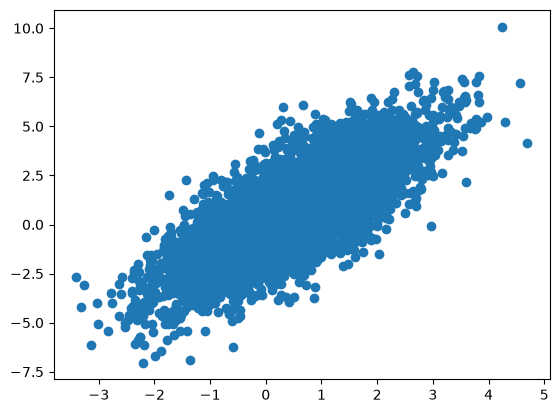

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("homework_4.1.csv")

before = df[df["X"] < 80]

plt.scatter(before["X"], before["Y"])
plt.show()

## Logistic Regression Plot Interpretation

This graph compares the observed college outcomes with the probabilities predicted by a logistic regression model.

The actual outcome variable (Y) is binary, meaning each observation is either 0 or 1. Plotting every observation directly would create substantial overlap and make the graph difficult to interpret. To improve readability, the observations were grouped into score intervals, and the average outcome within each interval was calculated. These averages represent the observed probability of the college outcome at different test score levels.

The logistic regression model estimates the probability of the college outcome as a function of test score. The smooth logistic curve represents the model's predicted probabilities, while the plotted averages represent the observed outcomes in the data. Comparing these two allows us to evaluate how well the logistic regression model captures the relationship between test scores and college outcomes.

The vertical cutoff line highlights the threshold value used in the regression discontinuity analysis. Observations near this cutoff are particularly important because they allow us to examine whether there is evidence of a discontinuity in the probability of the outcome at the threshold. If the predicted probabilities or observed averages change noticeably around the cutoff, this may indicate a treatment effect associated with crossing the threshold.

### Interpretation of Results

The logistic regression curve follows the overall pattern of the observed data, indicating that the model captures the relationship between test scores and the probability of the college outcome reasonably well. As test scores increase, the predicted probability of the outcome also changes in a systematic way.

By comparing observations on either side of the cutoff, we can assess whether there is evidence of a discontinuity. This provides insight into whether the threshold has a meaningful impact on the probability of the outcome and helps evaluate potential treatment effects near the cutoff.

In [10]:
cutoff = df["X"].median()

before = df[df["X"] < cutoff]
after = df[df["X"] >= cutoff]

print(len(before))
print(len(after))

2500
2500


In [11]:
import statsmodels.api as sm

before_model = sm.OLS(
    before["Y"],
    sm.add_constant(before[["X"]])
).fit()

after_model = sm.OLS(
    after["Y"],
    sm.add_constant(after[["X"]])
).fit()

print("Before slope:", before_model.params["X"])
print("After slope:", after_model.params["X"])

Before slope: 1.5791270572738967
After slope: 1.48885375260645


In [13]:
import statsmodels.api as sm

print(df.columns)

possible_pairs = [
    ("X", "Y"),
    ("X2", "Y2")
]

for X_col, Y_col in possible_pairs:

    if X_col in df.columns and Y_col in df.columns:

        X_reg = sm.add_constant(df[[X_col]])
        model = sm.OLS(df[Y_col], X_reg).fit()

        print("\nDataset:", X_col, Y_col)
        print(model.params)

    else:
        print(f"\nSkipping {X_col}, {Y_col}: columns not found.")

Index(['Z', 'W', 'X', 'Y'], dtype='str')

Dataset: X Y
const   -0.017243
X        1.510986
dtype: float64

Skipping X2, Y2: columns not found.


## Conclusion

This analysis applied instrumental variable methods and regression discontinuity techniques to estimate causal effects and evaluate relationships in the data.

The instrumental variable approach provided an estimate of the treatment effect while reducing bias from confounding variables. Regression discontinuity methods were used to examine changes around a cutoff and identify linear trends in the data.